In [1]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras.losses import CategoricalCrossentropy
from network import NetCNN1D


from mne.decoding import CSP
from sklearn.model_selection import StratifiedKFold

import numpy as np
import sys, os

import dataset_NewEEG
from config_NewEEG import Config

import matplotlib.pyplot as plt


import pandas as pd



config = Config()



# Choose from: 'CLeft', 'CRight', 'CUp' and 'CDown'
config.used_classes = ['CLeft', 'CRight']
config.session_type = 'S2'
session_ID_test = 1


config.t_start = 0 
config.t_end = 3.0

window_size = 2.0
stride = 1.0


config.n_csp_components = 3

# All available channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']
config.used_channels = ['FC3', 'FCz', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP3', 'CPz', 'CP4']


config.start = int(config.t_start * 250)
config.t_end = int(config.t_end * 250)


X_train_multiSess, y_train_multiSess = [], []
for i in range(1, 12):
    if i == session_ID_test: continue
    session_ID = f'I{i:02d}'
    X, y = dataset_NewEEG.session_sliced_dataset(config ,session_ID, window_size, stride)
    X_train_multiSess.append(X)
    y_train_multiSess.append(y)


X_train_multiSess = np.concatenate(X_train_multiSess)
y_train_multiSess = np.concatenate(y_train_multiSess)

X_test, y_test = dataset_NewEEG.session_sliced_dataset(config ,f'I{session_ID_test:02d}', window_size, stride)

print(X_train_multiSess.shape)
print(X_test.shape)


(632, 13, 500)
(62, 13, 500)



Epoch 1/100

15/15 [==============================] - 4s 48ms/step - loss: 0.7045 - acc: 0.4916 - val_loss: 0.6859 - val_acc: 0.4937
Epoch 2/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6808 - acc: 0.5549 - val_loss: 0.6824 - val_acc: 0.5570
Epoch 3/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6806 - acc: 0.5717 - val_loss: 0.6795 - val_acc: 0.6013
Epoch 4/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6762 - acc: 0.5992 - val_loss: 0.6796 - val_acc: 0.5949
Epoch 5/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6586 - acc: 0.5949 - val_loss: 0.6798 - val_acc: 0.5759
Epoch 6/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6561 - acc: 0.5970 - val_loss: 0.6824 - val_acc: 0.5759
Epoch 7/100
15/15 [==============================] - 0s 12ms/step - loss: 0.6617 - acc: 0.6245 - val_loss: 0.6832 - val_acc: 0.5823
Epoch 8/100
15/15 [==============================] - 0s 13ms/step - loss: 

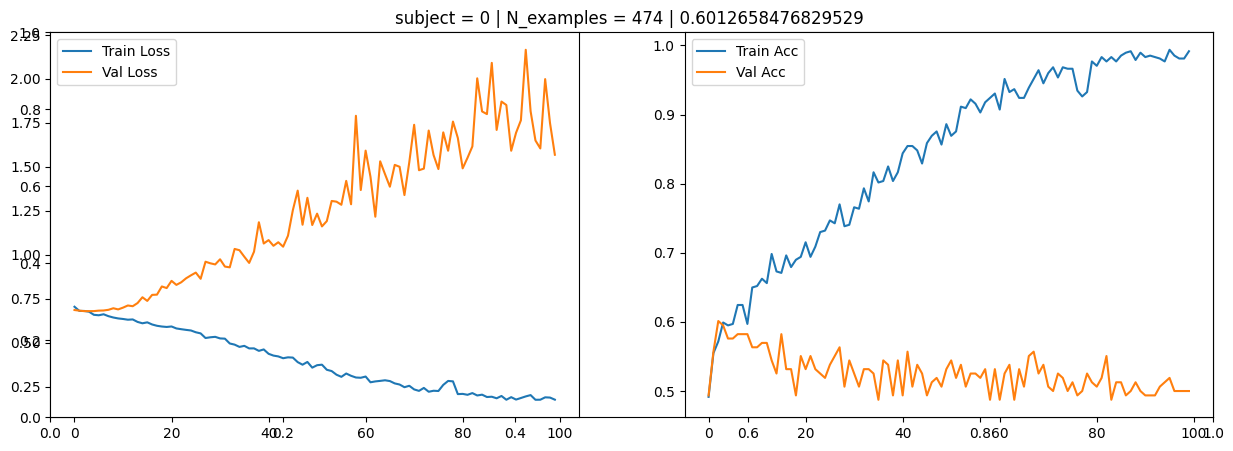

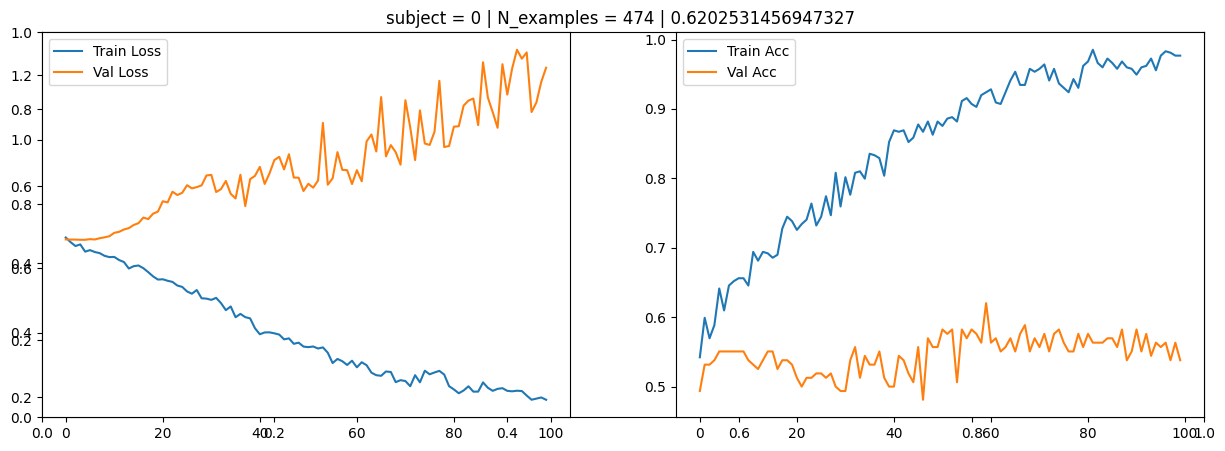

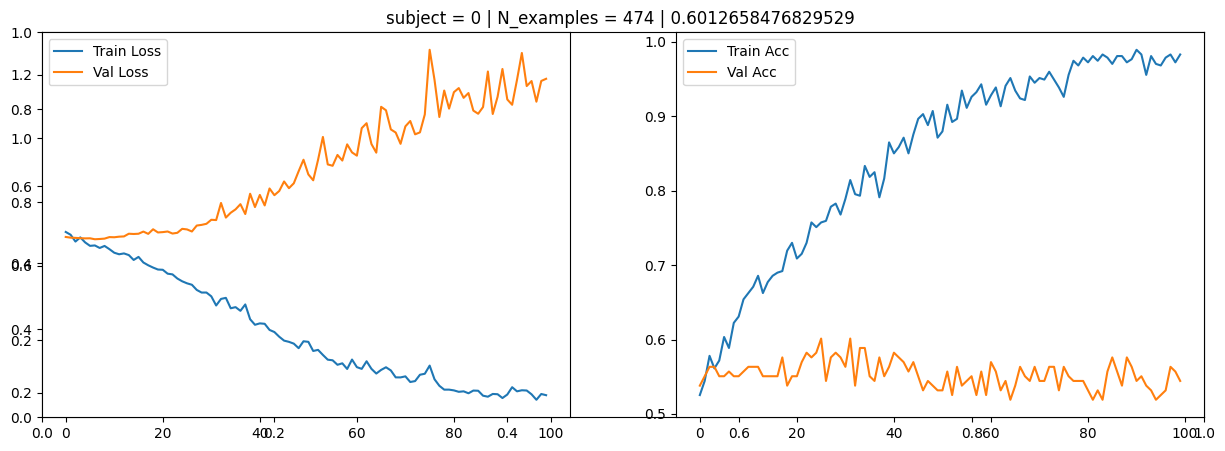

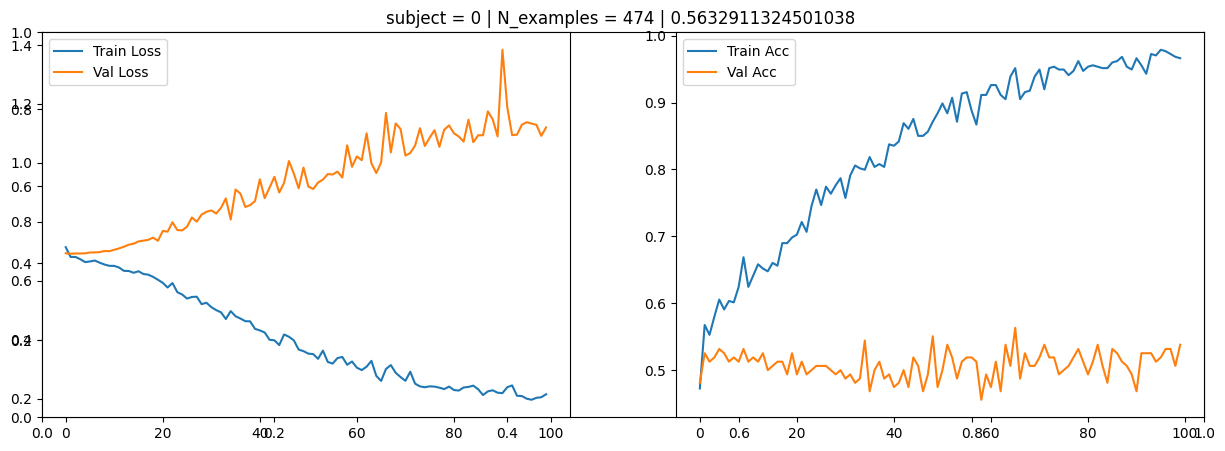

In [2]:
crossValidation_KF = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)


acc = []
Y_preds = []

shuffle_indices = np.random.permutation(len(y_train_multiSess))


X_train_multiSess = X_train_multiSess[shuffle_indices]
y_train_multiSess = y_train_multiSess[shuffle_indices]

for train_index, valid_index in crossValidation_KF.split(X_train_multiSess,y_train_multiSess):
    X_train = X_train_multiSess[train_index]
    Y_train = y_train_multiSess[train_index]
    X_valid = X_train_multiSess[valid_index]
    Y_valid = y_train_multiSess[valid_index]
    
    old_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')

    mu = X_train.mean()
    sigma = X_train.std( )

    #X_train = (X_train - mu) / sigma
    #X_valid =  (X_valid - mu) / sigma

    csp = CSP(n_components=config.n_csp_components, reg=None, log=None, norm_trace=False, transform_into='csp_space')

    X_train = csp.fit_transform(X_train, Y_train)
    X_valid = csp.transform(X_valid)


    X_train = X_train.transpose(0, 2, 1)
    X_valid = X_valid.transpose(0, 2, 1)

    Y_train = tf.keras.utils.to_categorical(Y_train, num_classes = 2)
    Y_valid = tf.keras.utils.to_categorical(Y_valid, num_classes = 2)



    model = NetCNN1D() 


    model.compile(
            loss= CategoricalCrossentropy(from_logits=True, label_smoothing=0.05),
            optimizer=keras.optimizers.Adam(learning_rate=5e-4, weight_decay = 2e-5), 
            metrics=[keras.metrics.CategoricalAccuracy(name='acc')]
    ) 



    sys.stdout.close()
    sys.stdout = old_stdout

    history = model.fit(X_train, Y_train, validation_data=(X_valid, Y_valid), epochs=100, batch_size=32, verbose=1)

    
    plt.figure(figsize=(15,5))
    plt.title(f"subject = {0} | N_examples = {X_train.shape[0]} | {max(history.history['val_acc'])} ")

    plt.subplot(1,2,1)
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.legend(["Train Loss", "Val Loss"])

    plt.subplot(1,2,2)
    plt.plot(history.history['acc'])
    plt.plot(history.history['val_acc'])
    plt.legend(["Train Acc", "Val Acc"])

    acc.append(max(history.history['val_acc']))



print("\n\n ================================== \n")
print(f"{100*np.mean(acc):.2f}% +- {100*np.std(acc):.1f}")